In [1]:
# setup and load libraries
import numpy as np
import main, cv2, torch, scipy.io
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from models.unet import init_UNet
from utils.dataset import CelebA
from inverse.orthogonal import LinearInverse, batch_recon
from torchmetrics import StructuralSimilarityIndexMeasure as MetricSSIM
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm

SSIM = MetricSSIM(data_range=1.0, sigma=1.0, reduction=None)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

save_figure = True
if save_figure:
    plt.rcParams['figure.dpi'] = 300

### Setup and Load Dataset

In [3]:
data = CelebA(from_numpy=True)
train_set = data.train_set()

N_TEST = 512
test_set = data.test_set()[:N_TEST]

In [4]:
def show_image(image_set):
    n_row = 2
    n_col = 12
    fig, axs = plt.subplots(n_row, n_col, figsize=(n_col * 2, 
                            n_row * 2), sharex=True, sharey=True)

    for idx in range(n_row * n_col):
        axs.flat[idx].imshow(image_set[idx], cmap='gray')
        axs.flat[idx].axis('off')

    fig.tight_layout()

In [5]:
test_numpy = test_set
test_torch = torch.tensor(test_set).permute([0, 3, 1, 2]).to(device)

In [6]:
# setup
train_torch = torch.from_numpy(train_set)
np_size = [*train_set.shape[-3:]]
im_size = test_torch.size()[1:]
n_pixel = np.prod(im_size)

avg_im = torch.mean(train_torch, dim=0).permute([2, 0, 1])

In [7]:
# load denoiser
model_path = './assets/unet_celeba.pt'
model = init_UNet()
model.load_state_dict(torch.load(model_path))
model = model.eval().to(device)

In [8]:
# compute PCA solution
image_vec = train_torch.permute([0, 3, 2, 1]).flatten(1).numpy()
pca = PCA(n_components=image_vec.shape[-1])
pca.fit(image_vec)

# n_comp, n_features
pcs = pca.components_
print('PCA Matrix', pcs.shape)

PCA Matrix (6400, 6400)


### Performance Curve

In [9]:
samples = [16, 32, 64, 128, 256]

base_path = './olm_result/CelebA/%d_SSIM_celeba.npy'
mse_path = './olm_result/CelebA/%d_MSE_celeba.npy'

# record 4 different error metric
# pca projection, PCA + denoiser, opt + denoiser
error = [np.zeros((len(samples))) for n in range(4)]

In [ ]:
ssim_loss = MetricSSIM(data_range=1.0, sigma=1.0, 
            reduction='elementwise_mean').to(device)

In [ ]:
for index in tqdm(range(len(samples))):
    n_sample = samples[index]
    
    # setup linear inverse object
    solver = LinearInverse(n_sample, im_size, model, avg_im).to(device)
    solver.h_init = 0.10
    solver.beta = 0.10
    
    solver.run_avg = True
    solver.num_avg = 8
    recon_batch = 32
    
    # 1. PCA projection
    Q = torch.from_numpy(pca.components_[:n_sample, :]).to(device)
    image_vec = test_torch.transpose(2, 3).flatten(1)
    recon_vec = image_vec @ Q.t() @ Q
    
    recon_shape = [-1, im_size[0], im_size[2], im_size[1]]
    recon_torch = recon_vec.reshape(recon_shape).transpose(2, 3)
    error[0][index] = ssim_loss(recon_torch, test_torch).item()
    
    # 2. PCA + Denoiser    
    solver.assign(torch.from_numpy(pca.components_[:n_sample, :]).to(device))
    solver_gpu = torch.nn.DataParallel(solver)    
    torch.manual_seed(0)
    
    recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
    error[1][index] = ssim_loss(recon, test_torch).item()
        
    # 3. MSE Measuremnet + Denoiser
    order = 5
    file_path = mse_path % n_sample
    with open(file_path, 'rb') as fl:
        for count in range(order):
            opt_mtx = np.load(fl)
            
    opt_mtx = torch.from_numpy(opt_mtx).to(device)
    solver.assign(opt_mtx)    
    solver_gpu = torch.nn.DataParallel(solver)
    torch.manual_seed(0)
    
    recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
    error[2][index] = ssim_loss(recon, test_torch).item()
    
    # 4. Optimized Measuremnet + Denoiser
    order = 5
    file_path = base_path % n_sample
    with open(file_path, 'rb') as fl:
        for count in range(order):
            opt_mtx = np.load(fl)

    opt_mtx = torch.from_numpy(opt_mtx).to(device)
    solver.assign(opt_mtx)    
    solver_gpu = torch.nn.DataParallel(solver)
    torch.manual_seed(0)
    
    recon = batch_recon(test_torch, solver_gpu, batch_size=recon_batch)
    error[3][index] = ssim_loss(recon, test_torch).item()

In [ ]:
fig = plt.figure(figsize=(6, 5))

n_curve = 4
colors = ['C0', 'C1', 'C3', 'C9']
for idx in range(n_curve):
    plt.plot(samples, error[idx], '-o', color=colors[idx])
    
plt.xscale('log', base=2)
plt.xticks(2 ** np.array([4, 5, 6, 7, 8]),
          2 ** np.array([4, 5, 6, 7, 8]))
plt.yticks([0.50, 0.60, 0.70, 0.80])

plt.xlabel('Number of Measurements')
plt.ylabel('SSIM')
plt.legend(['PC Projection', 'PC + Prior', 'OLM_MSE', 'OLM_SSIM'])

if save_figure:
    fig_name = 'ssim_celeba'
    fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')

plt.show()

In [ ]:
print('Delta SSIM', error[3] - error[1])

### Examples

In [10]:
n_sample = 32

In [11]:
loss = torch.nn.MSELoss(reduction='sum')

solver = LinearInverse(n_sample, im_size, model, avg_im).to(device)
solver.beta = 0.10
solver.h_init = 0.10
solver.run_avg = True 
solver.num_avg = 8

solver.assign(torch.from_numpy(pca.components_[:n_sample, :]).to(device))
solver_gpu = torch.nn.DataParallel(solver)
torch.manual_seed(0)

recon = batch_recon(test_torch, solver_gpu,
                   batch_size=32)

recon_pca = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()

In [12]:
# MSE Optimized
file_path = mse_path % n_sample

order = 5
with open(file_path, 'rb') as fl:
    for count in range(order):
        opt_mtx = np.load(fl)
        
opt_mtx_mse = torch.from_numpy(opt_mtx).to(device)

solver.assign(opt_mtx_mse)
solver_gpu = torch.nn.DataParallel(solver)
torch.manual_seed(0)

recon = batch_recon(test_torch, solver_gpu,
                   batch_size=32)

recon_dns = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()

In [13]:
# OLM + Prior
file_path = base_path % n_sample

order = 5
with open(file_path, 'rb') as fl:
    for count in range(order):
        opt_mtx = np.load(fl)
        
opt_mtx_ssim = torch.from_numpy(opt_mtx).to(device)

solver.assign(opt_mtx_ssim)
solver_gpu = torch.nn.DataParallel(solver)
torch.manual_seed(0)

recon = batch_recon(test_torch, solver_gpu, batch_size=32)
recon_opt = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()

In [14]:
ssim_pca = SSIM(torch.from_numpy(recon_pca).permute([0, 3, 1, 2]).to(device), test_torch).cpu().numpy()
ssim_dns = SSIM(torch.from_numpy(recon_dns).permute([0, 3, 1, 2]).to(device), test_torch).cpu().numpy()
ssim_opt = SSIM(torch.from_numpy(recon_opt).permute([0, 3, 1, 2]).to(device), test_torch).cpu().numpy()

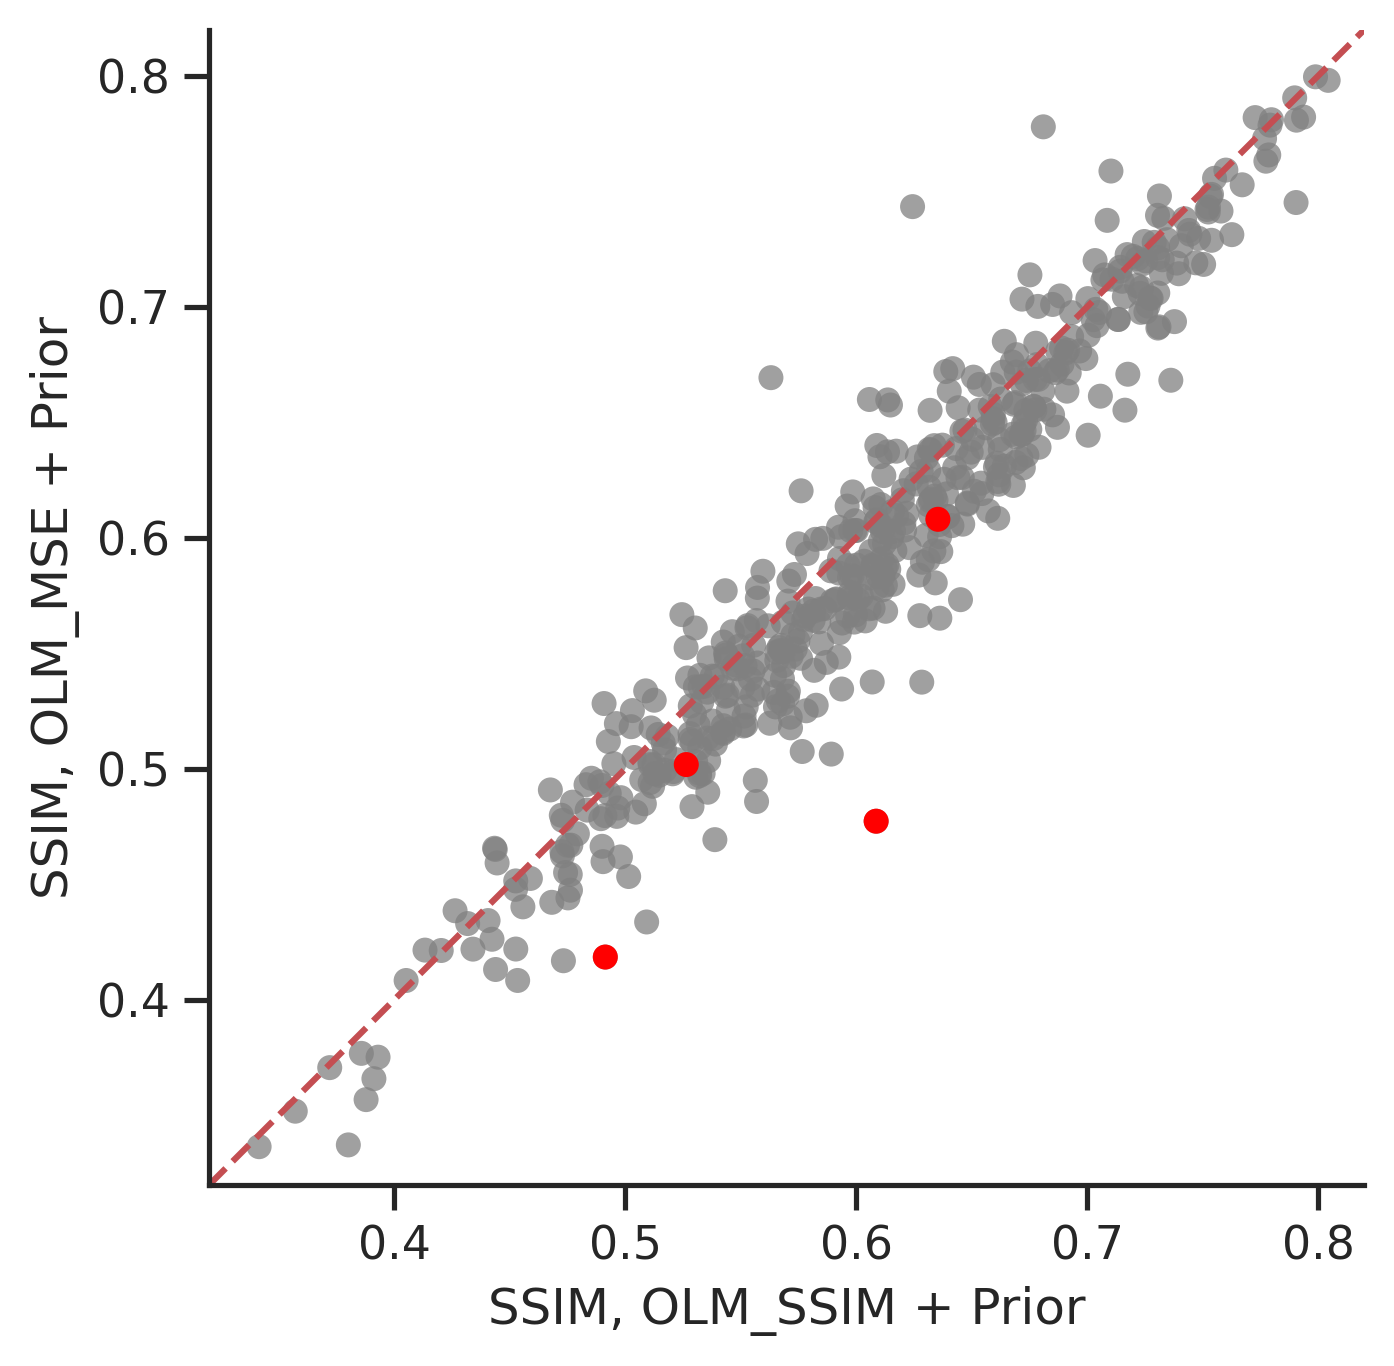

In [24]:
fig = plt.figure(figsize=(5, 5))
plt.scatter(ssim_opt, 
            ssim_dns, 
            c='gray', alpha=0.75,
           edgecolors='none')

img_idx = [63, 437, 313, 92]
for idx in img_idx:
    plt.scatter(ssim_opt[idx], 
                ssim_dns[idx], 
                c='red', alpha=1.0,
                edgecolors='none')
    
lb = 0.32
ub = 0.82
plt.plot([lb, ub], [lb, ub], '--r')

plt.xlabel('SSIM, OLM_SSIM + Prior')
plt.ylabel('SSIM, OLM_MSE + Prior')

plt.axis('square')

plt.xlim([lb, ub])
plt.ylim([lb, ub])

if save_figure:
    fig_name = 'ssim_scatter'
    fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')

plt.show()

Individual Samples

In [17]:
loss = torch.nn.MSELoss(reduction='sum')

solver = LinearInverse(n_sample, im_size, model, avg_im).to(device)
solver.beta = 0.10
solver.h_init = 0.10
solver.run_avg = False

solver.assign(torch.from_numpy(pca.components_[:n_sample, :]).to(device))
solver_gpu = torch.nn.DataParallel(solver)
torch.manual_seed(0)

recon = batch_recon(test_torch, solver_gpu, batch_size=32)
recon_pca = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()

In [18]:
# OLM_MSE
solver.assign(opt_mtx_mse)
solver_gpu = torch.nn.DataParallel(solver)
torch.manual_seed(0)

recon = batch_recon(test_torch, solver_gpu, batch_size=32)
recon_dns = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()

# OLM_SSIM
solver.assign(opt_mtx_ssim)
solver_gpu = torch.nn.DataParallel(solver)
torch.manual_seed(0)

recon = batch_recon(test_torch, solver_gpu, batch_size=32)
recon_opt = recon.detach().cpu().permute([0, 2, 3, 1]).numpy()

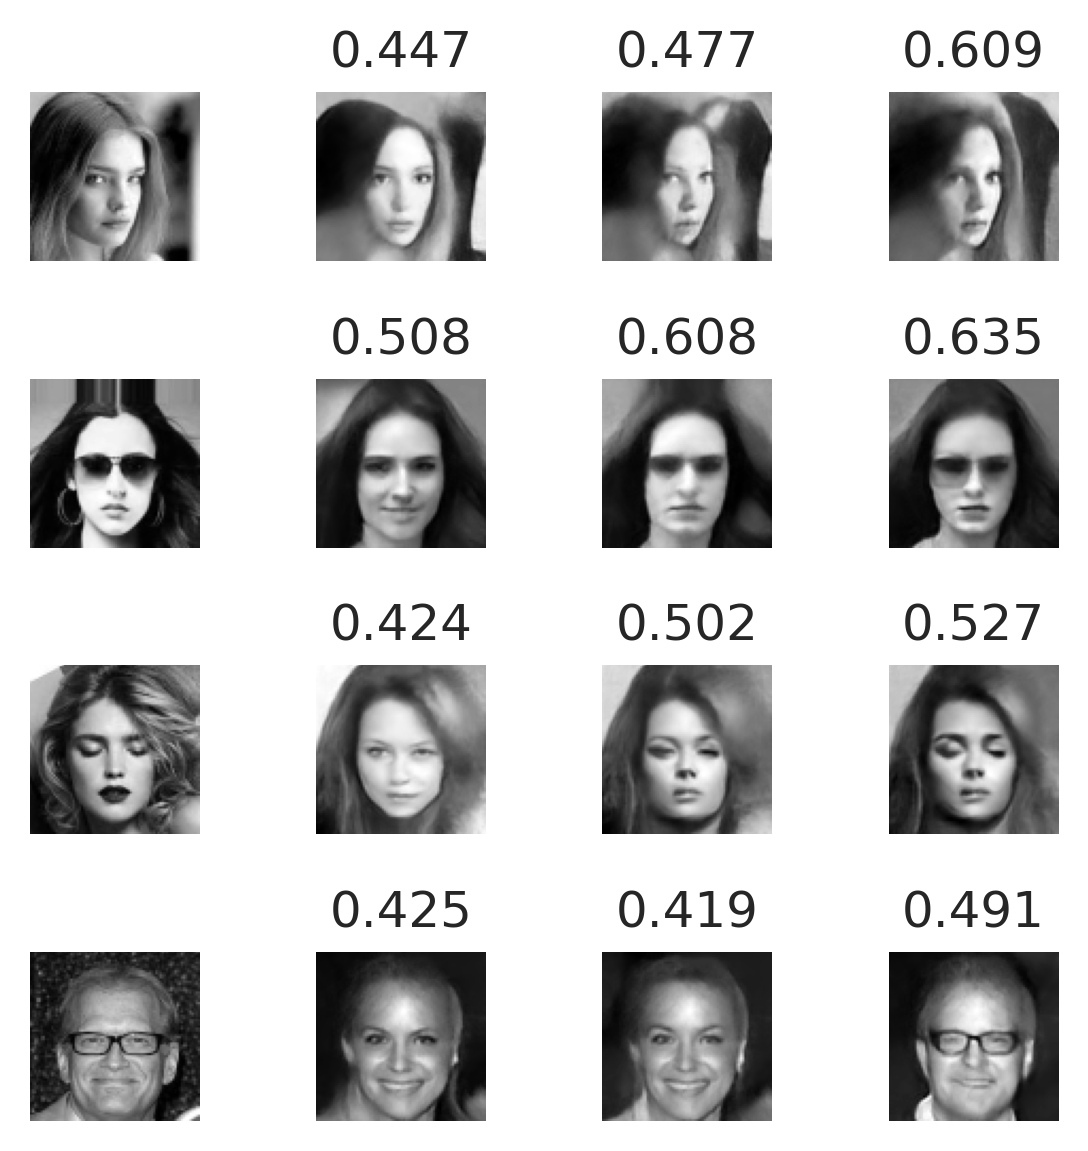

In [19]:
n_test = test_set.shape[0]
img_idx = [63, 437, 313, 92]

n_row = len(img_idx)
n_col = 4
fig, axs = plt.subplots(n_row, n_col, figsize=(n_col, n_row))

all_recon = [test_numpy, recon_pca, recon_dns, recon_opt]
all_ssim = [ssim_pca, ssim_dns, ssim_opt]
for idx in range(n_row):
    image_id = img_idx[idx]
    for idy in range(n_col):
        image = all_recon[idy][image_id]
        axs[idx, idy].imshow(image, cmap='gray')
        if idy > 0:
            axs[idx, idy].set_title('%.3f' % all_ssim[idy-1][image_id])
    
for ax in axs.flat:
    ax.axis('off')

plt.tight_layout()

if save_figure:
    fig_name = 'ssim_examples'
    fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')

plt.show()

### Measurement Vector

In [20]:
n_sample = 64
base_path = './olm_result/CelebA/%d_SSIM_celeba.npy'
file_path = base_path % n_sample

order = 5
with open(file_path, 'rb') as fl:
    for count in range(order):
        opt_mtx = np.load(fl)

target_shape = [-1, im_size[0], im_size[2], im_size[1]]
opt_image = opt_mtx.reshape(target_shape).transpose([0, 3, 2, 1])

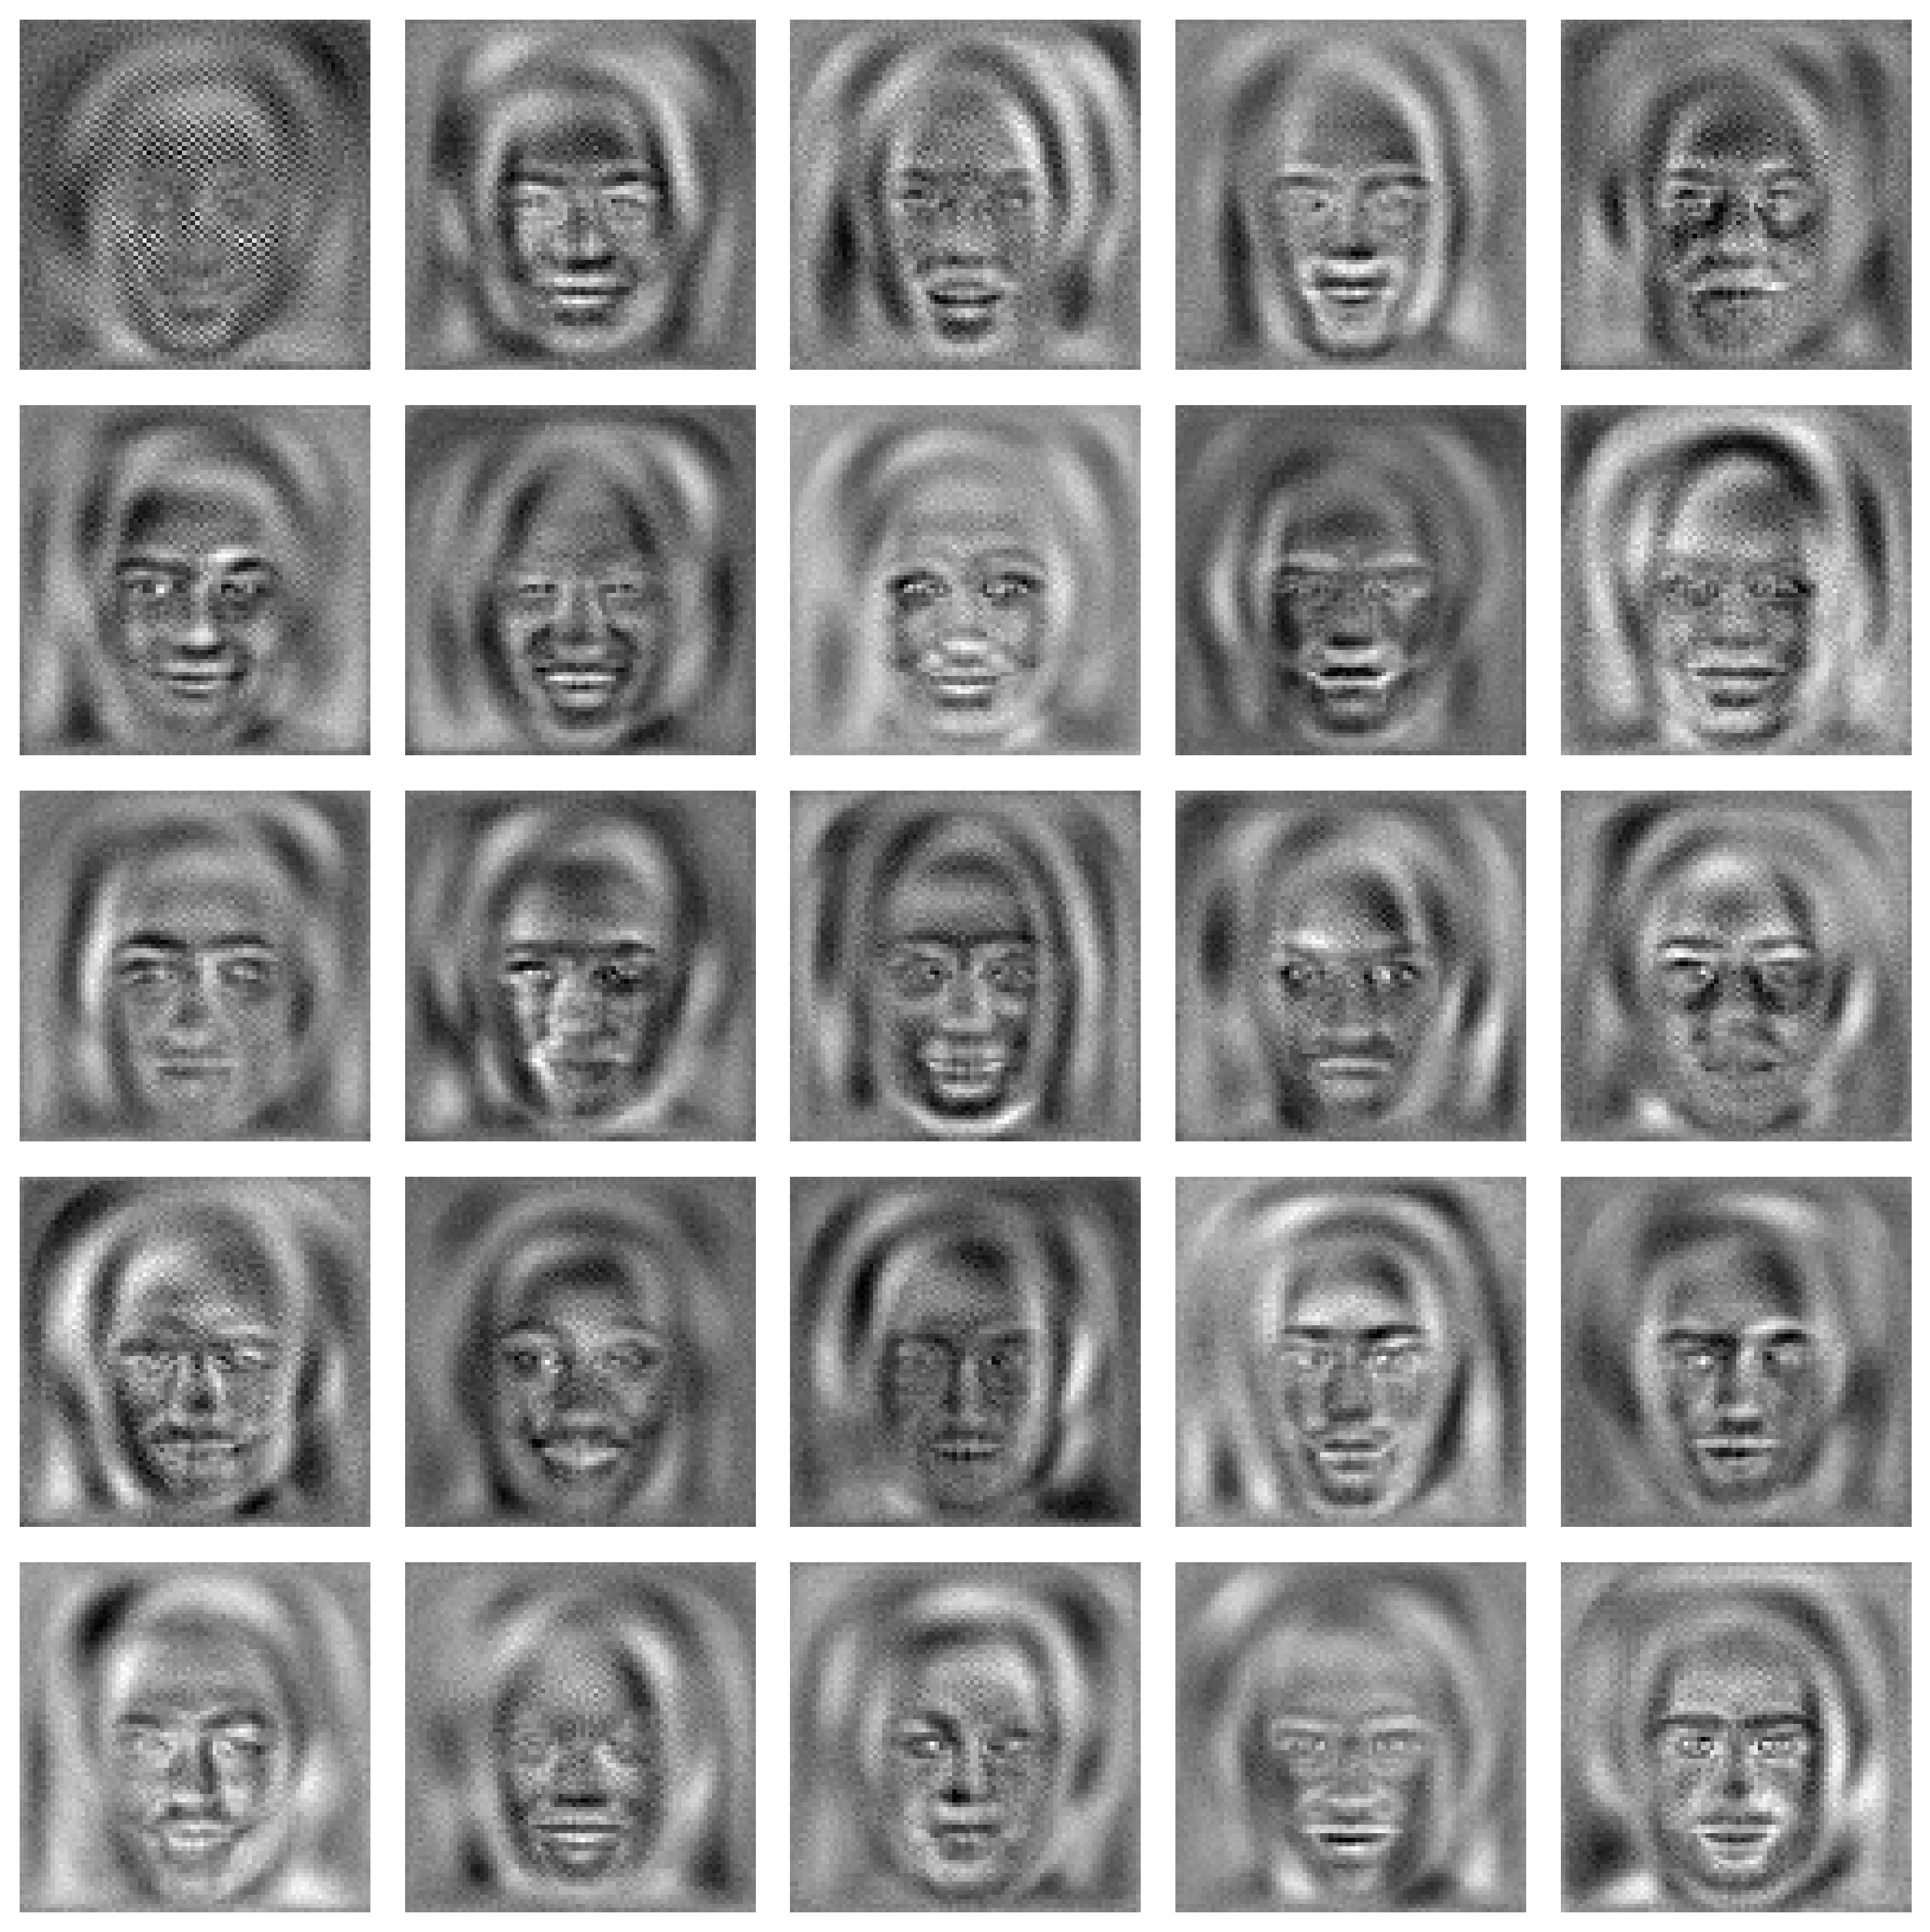

In [21]:
n_step = 2

n_row = 5
n_col = 5

fig, axs = plt.subplots(n_row, n_col, figsize=(n_col*2, n_row*2))
for idx in range(n_row * n_col):
    # normalization
    image = opt_image[idx * n_step]
    image = image - np.min(image)
    image = image / np.max(image)
    
    # show image
    axs.flat[idx].imshow(image, cmap='gray')
    axs.flat[idx].axis('off')
    
fig.tight_layout()

fig_name = 'ssim_vectors'
fig.savefig('./%s.pdf' % fig_name, bbox_inches='tight')